# CVD Heart Disease Prediction — Workflow

## Step 1: Encoding

In [2]:
import pandas as pd

df = pd.read_csv('CVD_cleaned.csv')
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [3]:
# Encode binary Yes/No columns
binary_cols = ['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer',
               'Depression', 'Arthritis', 'Smoking_History']
for col in binary_cols:
    df[col] = df[col].map({'No': 0, 'Yes': 1})

# Sex
df['Sex'] = df['Sex'].map({'Female': 0, 'Male': 1})

In [4]:
# General_Health (ordinal: Poor -> Excellent)
health_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4}
df['General_Health'] = df['General_Health'].map(health_order)

# Checkup (ordinal: longest ago -> most recent)
checkup_order = {
    'Never': 0,
    '5 or more years ago': 1,
    'Within the past 5 years': 2,
    'Within the past 2 years': 3,
    'Within the past year': 4
}
df['Checkup'] = df['Checkup'].map(checkup_order)

In [5]:
# Diabetes (keep all 4 levels)
diabetes_order = {
    'No': 0,
    'No, pre-diabetes or borderline diabetes': 1,
    'Yes, but female told only during pregnancy': 2,
    'Yes': 3
}
df['Diabetes'] = df['Diabetes'].map(diabetes_order)

# Age_Category (ordinal, increasing age)
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54',
             '55-59','60-64','65-69','70-74','75-79','80+']
age_map = {age: i for i, age in enumerate(age_order)}
df['Age_Category'] = df['Age_Category'].map(age_map)

In [6]:
# Check result
print('Missing values after encoding:', df.isnull().sum().sum())
df.dtypes

Missing values after encoding: 0


General_Health                    int64
Checkup                           int64
Exercise                          int64
Heart_Disease                     int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                      int64
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object

In [7]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,3,0,0,0,0,0,0,1,0,10,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,3,4,0,1,0,0,0,3,0,0,10,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,3,4,1,0,0,0,0,3,0,0,8,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,0,4,1,1,0,0,0,3,0,1,11,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,2,4,0,0,0,0,0,0,0,1,12,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


In [8]:
df.to_csv('CVD_encoded.csv', index=False)

## Step 2: Feature Engineering


New features added:
- `BMI_Category`: ordinal bin of BMI (Underweight / Normal / Overweight / Obese)
- `Comorbidity_Count`: number of existing conditions (Skin_Cancer, Other_Cancer, Depression, Arthritis, Diabetes)
- `Unhealthy_Diet_Score`: FriedPotato_Consumption minus (Fruit_Consumption + Green_Vegetables_Consumption)

In [9]:
# BMI_Category (ordinal: Underweight < Normal < Overweight < Obese)
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Comorbidity_Count: how many existing conditions a person has
df['Comorbidity_Count'] = (
    df['Skin_Cancer'] + df['Other_Cancer'] + df['Depression'] +
    df['Arthritis'] + (df['Diabetes'] >= 1).astype(int)
)

# Unhealthy_Diet_Score: fried potato consumption relative to fruit/veggie consumption
df['Unhealthy_Diet_Score'] = df['FriedPotato_Consumption'] - (
    df['Fruit_Consumption'] + df['Green_Vegetables_Consumption']
)

df[['BMI_Category', 'Comorbidity_Count', 'Unhealthy_Diet_Score']].describe()

,BMI_Category,Comorbidity_Count,Unhealthy_Diet_Score
count,308854.000000,308854.000000,308854.000000
mean,2.019491,0.882478,-38.649025
std,0.829738,0.961059,33.779031
min,0.000000,0.000000,-240.000000
25%,1.000000,0.000000,-58.000000
50%,2.000000,1.000000,-32.000000
75%,3.000000,1.000000,-14.000000
max,3.000000,5.000000,120.000000


In [10]:
df.to_csv('CVD_encoded.csv', index=False)
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,BMI_Category,Comorbidity_Count,Unhealthy_Diet_Score
0,0,3,0,0,0,0,0,0,1,0,...,32.66,14.54,1,0.0,30.0,16.0,12.0,0,1,-34.0
1,3,4,0,1,0,0,0,3,0,0,...,77.11,28.29,0,0.0,30.0,0.0,4.0,2,1,-26.0
2,3,4,1,0,0,0,0,3,0,0,...,88.45,33.47,0,4.0,12.0,3.0,16.0,3,1,1.0
3,0,4,1,1,0,0,0,3,0,1,...,93.44,28.73,0,0.0,30.0,30.0,8.0,2,1,-52.0
4,2,4,0,0,0,0,0,0,0,1,...,88.45,24.37,1,0.0,8.0,4.0,0.0,1,0,-12.0


## Step 3: Exploratory Data Analysis (EDA)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

### Target distribution

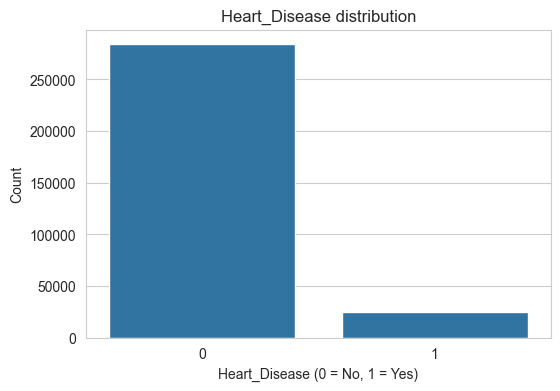

In [12]:
sns.countplot(data=df, x='Heart_Disease')
plt.title('Heart_Disease distribution')
plt.xlabel('Heart_Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### Distribution of continuous variables

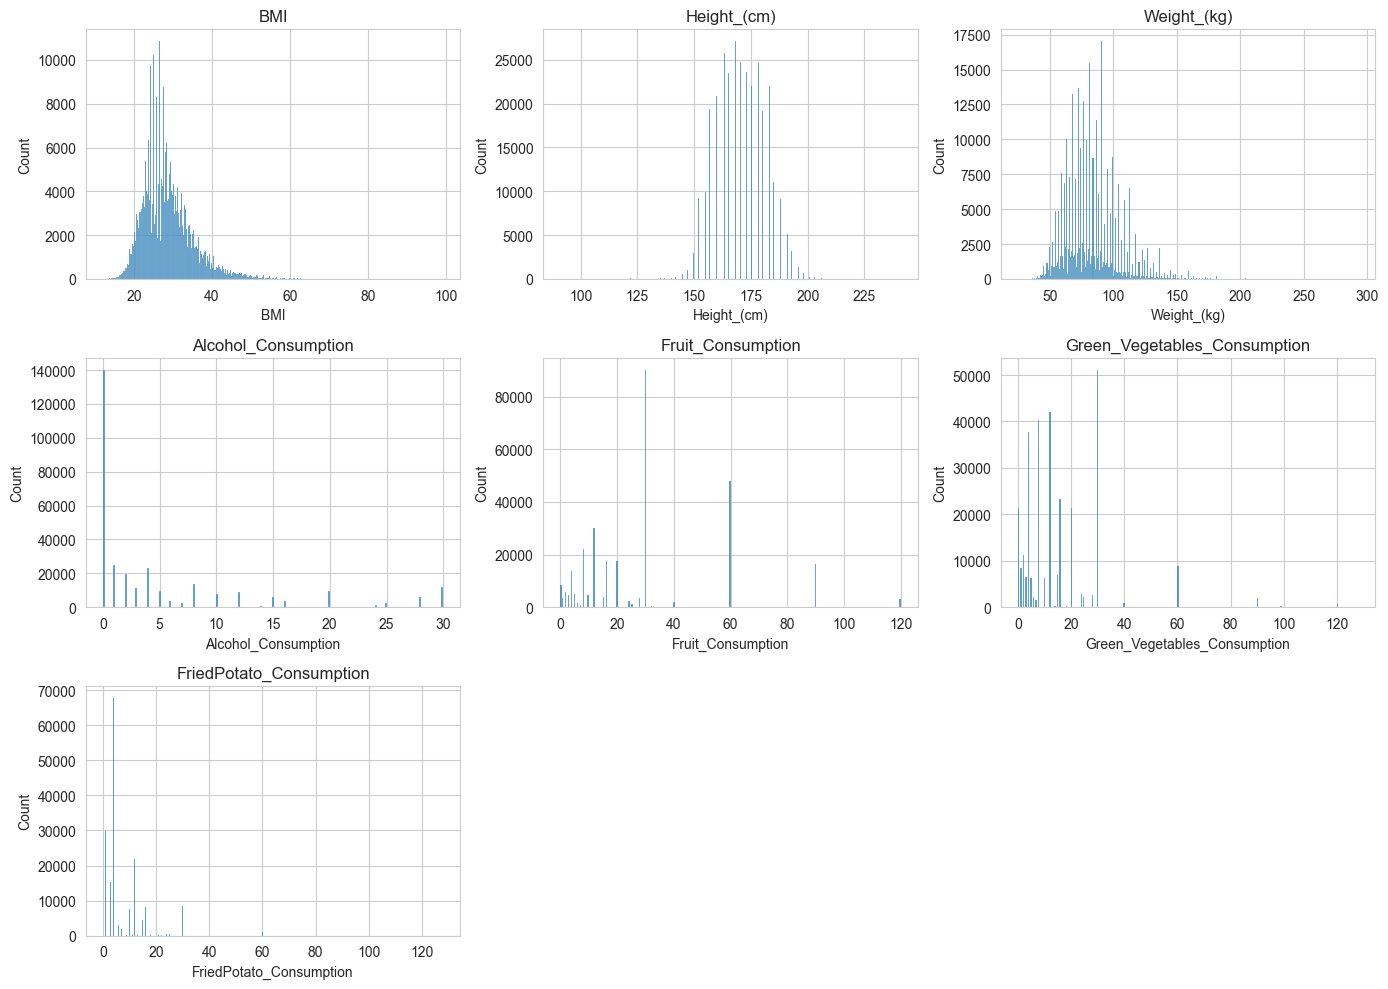

In [13]:
continuous_cols = ['BMI', 'Height_(cm)', 'Weight_(kg)', 'Alcohol_Consumption',
                    'Fruit_Consumption', 'Green_Vegetables_Consumption',
                    'FriedPotato_Consumption']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Heart_Disease rate by General_Health

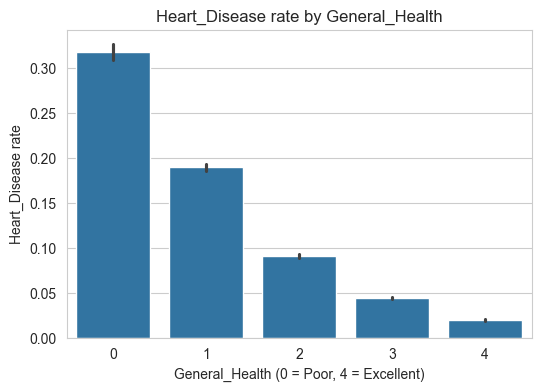

In [14]:
sns.barplot(data=df, x='General_Health', y='Heart_Disease')
plt.title('Heart_Disease rate by General_Health')
plt.xlabel('General_Health (0 = Poor, 4 = Excellent)')
plt.ylabel('Heart_Disease rate')
plt.show()

### Heart_Disease rate by Age_Category

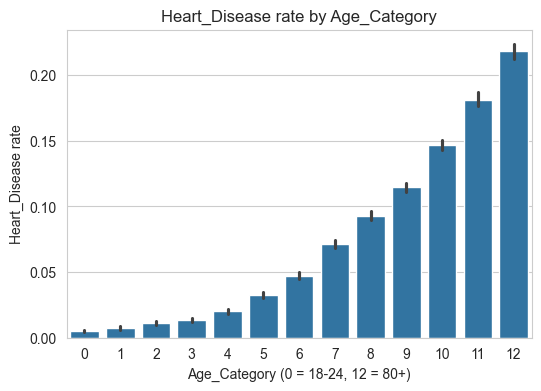

In [15]:
sns.barplot(data=df, x='Age_Category', y='Heart_Disease')
plt.title('Heart_Disease rate by Age_Category')
plt.xlabel('Age_Category (0 = 18-24, 12 = 80+)')
plt.ylabel('Heart_Disease rate')
plt.show()

### Correlation matrix

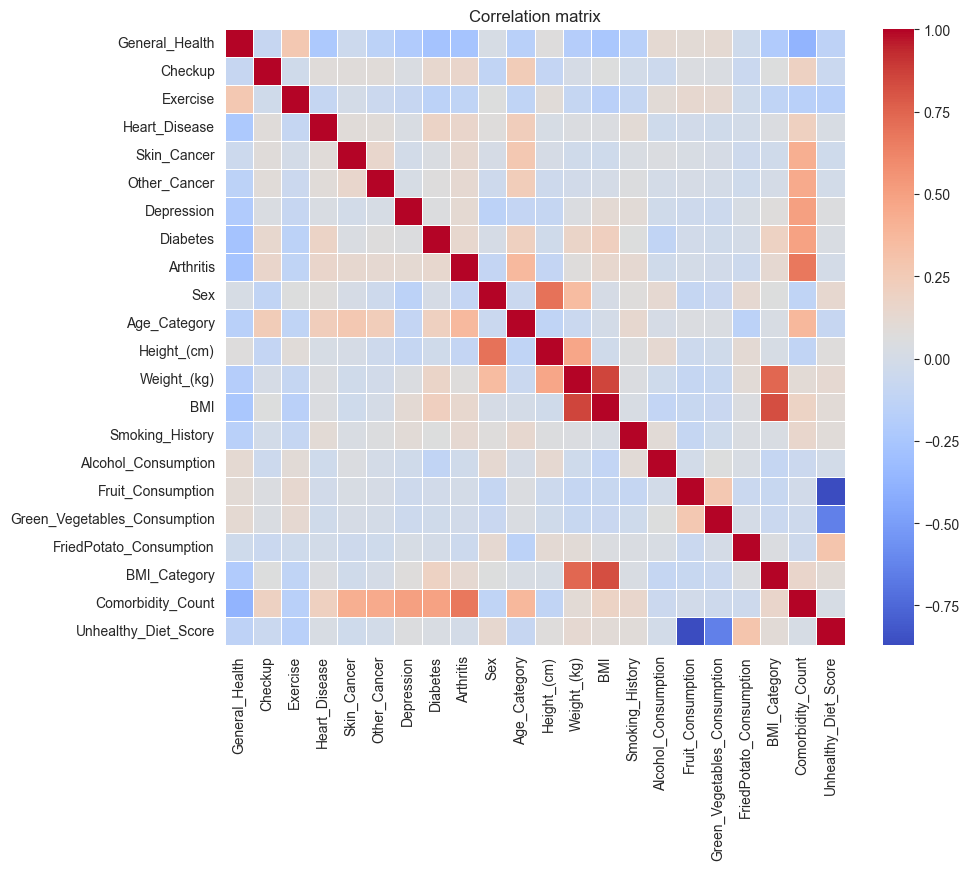

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation matrix')
plt.show()

## Step 4: Advanced Data Visualization

This section demonstrates eight advanced chart types: Histogram and Bar Chart
(already used in Step 3), plus Waffle Chart, Area Plot, Pie Chart, Scatter Plot,
Word Cloud, and Choropleth Map, added here. `CVD_cleaned` has no geographic
column, so the Choropleth Map uses a small, clearly-labeled external dataset
(2019 CDC state-level heart disease death rates, public domain) instead of the
project's own data.


In [17]:
from pywaffle import Waffle
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

### Waffle Chart — proportion of General_Health categories

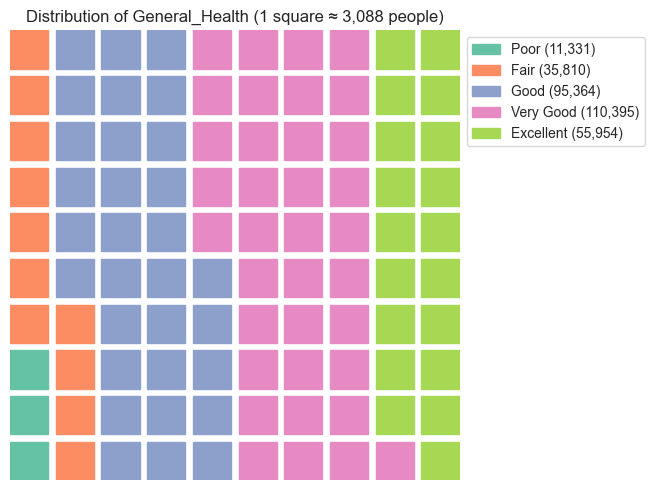

In [ ]:
health_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
health_counts = df['General_Health'].value_counts().sort_index()

block_size = health_counts.sum() // 100  # mỗi ô ≈ 1% dân số, lưới 10x10
waffle_data = dict(zip(health_labels, (health_counts // block_size).values))

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    
    columns=10,
    values=waffle_data,
    title={'label': f'Distribution of General_Health (1 square ≈ {block_size:,} people)', 'fontsize': 12},
    labels=[f'{k} ({v:,})' for k, v in zip(health_labels, health_counts.values)],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(8, 5)
)
plt.show()
plt.close('all')

### Area Plot — average risk indicators by age group

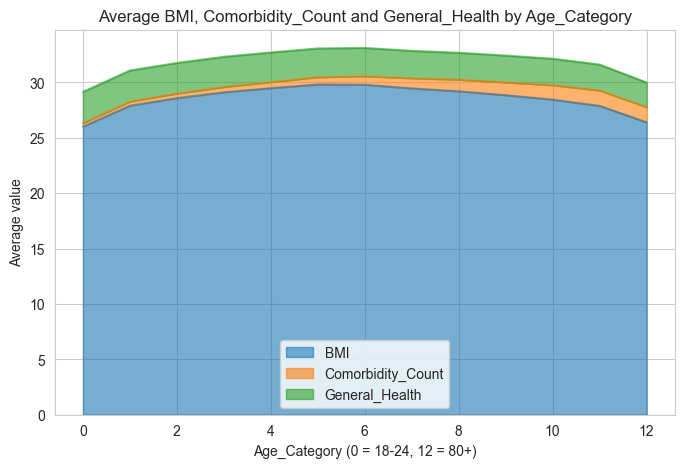

In [19]:
age_trend = df.groupby('Age_Category')[['BMI', 'Comorbidity_Count', 'General_Health']].mean()

age_trend.plot.area(figsize=(8, 5), alpha=0.6)
plt.title('Average BMI, Comorbidity_Count and General_Health by Age_Category')
plt.xlabel('Age_Category (0 = 18-24, 12 = 80+)')
plt.ylabel('Average value')
plt.show()
plt.close('all')

### Pie Chart — Diabetes status

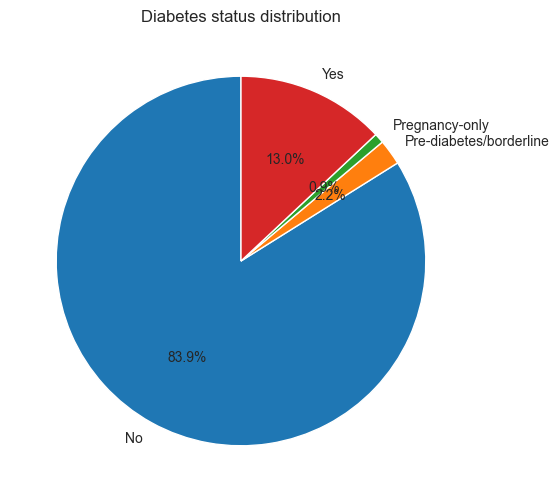

In [20]:
diabetes_labels = ['No', 'Pre-diabetes/borderline', 'Pregnancy-only', 'Yes']
diabetes_counts = df['Diabetes'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(diabetes_counts, labels=diabetes_labels, autopct='%1.1f%%', startangle=90)
plt.title('Diabetes status distribution')
plt.show()
plt.close('all')

### Scatter Plot — BMI vs. Age_Category by Heart_Disease

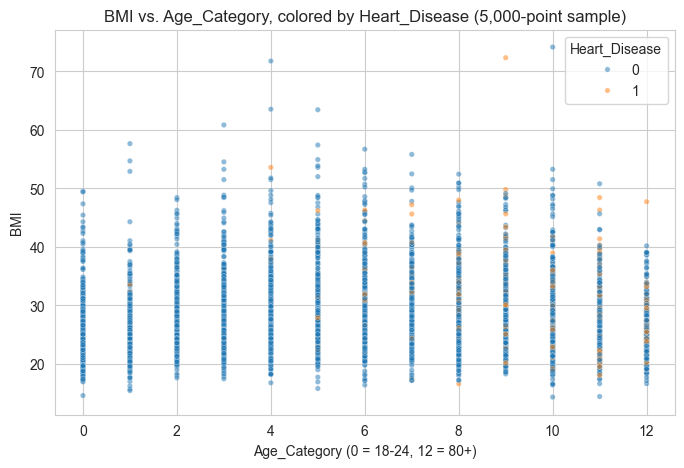

In [21]:
sample = df.sample(5000, random_state=42)  # subsample for a readable scatter plot

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='Age_Category', y='BMI', hue='Heart_Disease', alpha=0.5, s=15)
plt.title('BMI vs. Age_Category, colored by Heart_Disease (5,000-point sample)')
plt.xlabel('Age_Category (0 = 18-24, 12 = 80+)')
plt.show()
plt.close('all')

### Word Cloud — feature correlation with Heart_Disease


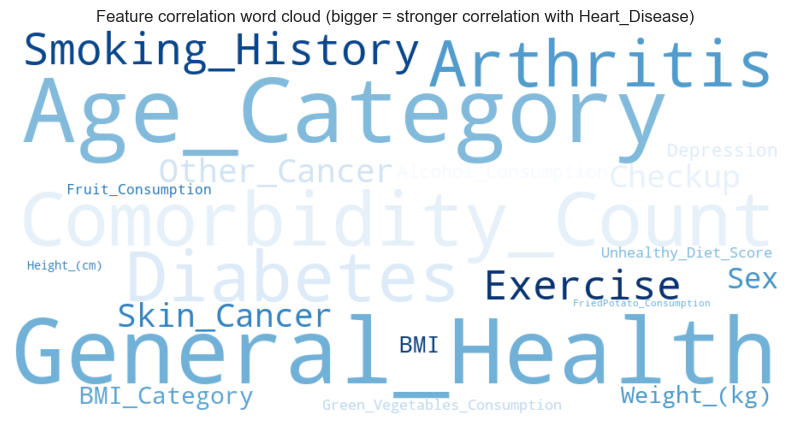

In [22]:
# Word cloud sized by absolute correlation with Heart_Disease.
# (Model-based feature importance isn't available yet at this point in the
# notebook now that Advanced Visualization runs before model training — see
# Step 12 for the XGBoost-based importance ranking instead.)
corr_importance = df.corr(numeric_only=True)['Heart_Disease'].drop('Heart_Disease').abs()
corr_importance = corr_importance.sort_values(ascending=False)
importance_dict = corr_importance.to_dict()

wc = WordCloud(width=900, height=450, background_color='white', colormap='Blues')
wc.generate_from_frequencies(importance_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Feature correlation word cloud (bigger = stronger correlation with Heart_Disease)')
plt.show()
plt.close('all')


### Choropleth Map — U.S. heart disease death rate by state (external context data)

`CVD_cleaned` has no state/location column, so this map uses public-domain 2019
age-adjusted heart disease death rates per state from the CDC (NCHS Data Brief
No. 425), shown here for real-world context rather than as project data.

In [23]:
import plotly.graph_objects as go

# Public-domain data: CDC NCHS Data Brief No. 425 (2019 age-adjusted heart disease
# death rate per 100,000 population, by state)
state_death_rates = {
    'AL': 219.6, 'AK': 129.7, 'AZ': 134.0, 'AR': 226.5, 'CA': 136.9, 'CO': 127.7,
    'CT': 143.1, 'DE': 154.3, 'FL': 140.1, 'GA': 175.5, 'HI': 120.3, 'ID': 150.7,
    'IL': 162.0, 'IN': 178.9, 'IA': 172.9, 'KS': 166.0, 'KY': 196.4, 'LA': 207.8,
    'ME': 142.4, 'MD': 159.3, 'MA': 127.2, 'MI': 193.8, 'MN': 116.7, 'MS': 226.7,
    'MO': 187.0, 'MT': 157.1, 'NE': 144.9, 'NV': 198.1, 'NH': 143.4, 'NJ': 158.0,
    'NM': 158.2, 'NY': 166.6, 'NC': 154.7, 'ND': 147.7, 'OH': 188.8, 'OK': 231.4,
    'OR': 131.0, 'PA': 172.9, 'RI': 159.3, 'SC': 164.0, 'SD': 158.1, 'TN': 202.8,
    'TX': 163.4, 'UT': 146.5, 'VT': 151.6, 'VA': 149.1, 'WA': 134.8, 'WV': 197.4,
    'WI': 158.8, 'WY': 150.4,
}

fig = go.Figure(data=go.Choropleth(
    locations=list(state_death_rates.keys()),
    z=list(state_death_rates.values()),
    locationmode='USA-states',
    colorscale='Reds',
    colorbar_title='Deaths per 100,000',
))
fig.update_layout(
    title_text='2019 Age-Adjusted Heart Disease Death Rate by State (CDC)',
    geo_scope='usa',
)
fig.show()

## Step 5: Train/Test Split (baseline)


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (247083, 21)
Test: (61771, 21)


## Step 6: Class Imbalance Check


In [25]:
print('Class ratio in train set:')
print(y_train.value_counts(normalize=True))

# scale_pos_weight for boosting models (count of class 0 / count of class 1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', scale_pos_weight)

Class ratio in train set:
Heart_Disease
0    0.919149
1    0.080851
Name: proportion, dtype: float64
scale_pos_weight: 11.368373629674124


## Step 7: Model Training — Brute Force Across Seeds

Trains multiple models (Logistic Regression, Random Forest, XGBoost, LightGBM),
each with several different `train_test_split` seeds, to see how stable performance
is and to avoid picking a model that just got a lucky split.


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

seeds = [0, 42, 123]

In [27]:
def get_models(scale_pos_weight):
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'RandomForest': RandomForestClassifier(n_estimators=120, class_weight='balanced',
                                                random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=300, eval_metric='logloss',
                                  scale_pos_weight=scale_pos_weight, n_jobs=-1),
        'LightGBM': LGBMClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight,
                                    n_jobs=-1, verbose=-1),
    }

In [28]:
results = []

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    models = get_models(spw)

    for model_name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        elapsed = time.time() - start

        results.append({
            'model': model_name,
            'seed': seed,
            'accuracy': acc,
            'f1_score': f1,
            'train_time_sec': round(elapsed, 1)
        })

        print(f'{model_name:20s} | seed={seed:4d} | acc={acc:.4f} | f1={f1:.4f} | {elapsed:.1f}s')

        del model
        import gc; gc.collect()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed=   0 | acc=0.7393 | f1=0.3290 | 8.9s
RandomForest         | seed=   0 | acc=0.9187 | f1=0.0478 | 6.0s
XGBoost              | seed=   0 | acc=0.7736 | f1=0.3289 | 1.4s
LightGBM             | seed=   0 | acc=0.7405 | f1=0.3280 | 2.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed=  42 | acc=0.7369 | f1=0.3309 | 9.1s
RandomForest         | seed=  42 | acc=0.9192 | f1=0.0535 | 7.4s
XGBoost              | seed=  42 | acc=0.7727 | f1=0.3292 | 1.4s
LightGBM             | seed=  42 | acc=0.7356 | f1=0.3276 | 2.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed= 123 | acc=0.7331 | f1=0.3247 | 9.7s
RandomForest         | seed= 123 | acc=0.9190 | f1=0.0490 | 7.2s
XGBoost              | seed= 123 | acc=0.7683 | f1=0.3258 | 1.7s
LightGBM             | seed= 123 | acc=0.7322 | f1=0.3224 | 2.5s


## Step 8: Results Log & Ranking


In [29]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(
    by=['accuracy', 'f1_score'], ascending=False
).reset_index(drop=True)

results_df_sorted

,model,seed,accuracy,f1_score,train_time_sec
0,RandomForest,42,0.919185,0.053470,7.4
1,RandomForest,123,0.918975,0.049021,7.2
2,RandomForest,0,0.918651,0.047754,6.0
3,XGBoost,0,0.773583,0.328887,1.4
4,XGBoost,42,0.772676,0.329161,1.4
5,XGBoost,123,0.768273,0.325765,1.7
6,LightGBM,0,0.740509,0.328009,2.3
7,LogisticRegression,0,0.739279,0.328986,8.9
8,LogisticRegression,42,0.736915,0.330877,9.1
9,LightGBM,42,0.735604,0.327569,2.4


### Average performance per model (across seeds)

In [30]:
summary = results_df.groupby('model')[['accuracy', 'f1_score']].agg(['mean', 'std'])
summary.sort_values(('accuracy', 'mean'), ascending=False)

accuracy            f1_score          
                        mean       std      mean       std
model                                                     
RandomForest        0.918937  0.000269  0.050082  0.003002
XGBoost             0.771511  0.002840  0.327938  0.001886
LogisticRegression  0.736441  0.003103  0.328184  0.003170
LightGBM            0.736095  0.004190  0.325997  0.003113

## Step 9: More Models, Accuracy-Priority (no imbalance correction)

Removing `scale_pos_weight` / `class_weight='balanced'` lets models lean toward the
majority class, which pushes accuracy above 0.9 — but F1 on the minority class
(actual heart disease cases) will drop. Both metrics are logged so the trade-off
stays visible.


In [31]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

def get_models_no_balance():
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
        'ExtraTrees': ExtraTreesClassifier(n_estimators=120, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss', n_jobs=-1),
        'LightGBM': LGBMClassifier(n_estimators=200, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=150, verbose=0, random_state=42),
        'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
        'GaussianNB': GaussianNB(),
    }

In [32]:
results_acc_priority = []

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    models = get_models_no_balance()

    for model_name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        elapsed = time.time() - start

        results_acc_priority.append({
            'model': model_name,
            'seed': seed,
            'accuracy': acc,
            'f1_score': f1,
            'train_time_sec': round(elapsed, 1)
        })

        print(f'{model_name:20s} | seed={seed:4d} | acc={acc:.4f} | f1={f1:.4f} | {elapsed:.1f}s')

        del model
        import gc; gc.collect()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed=   0 | acc=0.9195 | f1=0.1181 | 7.6s
RandomForest         | seed=   0 | acc=0.9193 | f1=0.0701 | 7.3s
ExtraTrees           | seed=   0 | acc=0.9166 | f1=0.1074 | 5.2s
XGBoost              | seed=   0 | acc=0.9184 | f1=0.1105 | 1.0s
LightGBM             | seed=   0 | acc=0.9197 | f1=0.0645 | 1.8s
CatBoost             | seed=   0 | acc=0.9181 | f1=0.0987 | 2.5s
HistGradientBoosting | seed=   0 | acc=0.9195 | f1=0.0482 | 1.9s
AdaBoost             | seed=   0 | acc=0.9198 | f1=0.1250 | 9.3s
GaussianNB           | seed=   0 | acc=0.8163 | f1=0.3087 | 0.1s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed=  42 | acc=0.9193 | f1=0.1106 | 7.0s
RandomForest         | seed=  42 | acc=0.9188 | f1=0.0704 | 6.0s
ExtraTrees           | seed=  42 | acc=0.9164 | f1=0.1090 | 5.8s
XGBoost              | seed=  42 | acc=0.9187 | f1=0.1199 | 1.0s
LightGBM             | seed=  42 | acc=0.9193 | f1=0.0635 | 1.9s
CatBoost             | seed=  42 | acc=0.9185 | f1=0.1049 | 2.7s
HistGradientBoosting | seed=  42 | acc=0.9195 | f1=0.0475 | 2.0s
AdaBoost             | seed=  42 | acc=0.9191 | f1=0.1272 | 9.9s
GaussianNB           | seed=  42 | acc=0.8180 | f1=0.3133 | 0.1s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   | seed= 123 | acc=0.9197 | f1=0.1193 | 7.5s
RandomForest         | seed= 123 | acc=0.9188 | f1=0.0632 | 6.5s
ExtraTrees           | seed= 123 | acc=0.9164 | f1=0.1026 | 5.8s
XGBoost              | seed= 123 | acc=0.9182 | f1=0.1099 | 1.0s
LightGBM             | seed= 123 | acc=0.9199 | f1=0.0639 | 1.8s
CatBoost             | seed= 123 | acc=0.9185 | f1=0.1023 | 2.9s
HistGradientBoosting | seed= 123 | acc=0.9197 | f1=0.0443 | 2.4s
AdaBoost             | seed= 123 | acc=0.9194 | f1=0.1167 | 9.6s
GaussianNB           | seed= 123 | acc=0.8134 | f1=0.3084 | 0.1s


In [33]:
results_acc_df = pd.DataFrame(results_acc_priority)
results_acc_sorted = results_acc_df.sort_values(
    by=['accuracy', 'f1_score'], ascending=False
).reset_index(drop=True)

results_acc_sorted

,model,seed,accuracy,f1_score,train_time_sec
0,LightGBM,123,0.919881,0.063930,1.8
1,AdaBoost,0,0.919784,0.125022,9.3
2,HistGradientBoosting,123,0.919736,0.044333,2.4
3,LogisticRegression,123,0.919671,0.119276,7.5
4,LightGBM,0,0.919671,0.064480,1.8
5,LogisticRegression,0,0.919525,0.118148,7.6
6,HistGradientBoosting,0,0.919493,0.048230,1.9
7,HistGradientBoosting,42,0.919461,0.047482,2.0
8,AdaBoost,123,0.919396,0.116729,9.6
9,LightGBM,42,0.919347,0.063534,1.9


### Average performance per model (across seeds)

In [34]:
summary_acc = results_acc_df.groupby('model')[['accuracy', 'f1_score']].agg(['mean', 'std'])
summary_acc.sort_values(('accuracy', 'mean'), ascending=False)

accuracy            f1_score          
                          mean       std      mean       std
model                                                       
LightGBM              0.919633  0.000269  0.063981  0.000475
HistGradientBoosting  0.919563  0.000150  0.046682  0.002068
LogisticRegression    0.919488  0.000205  0.116000  0.004731
AdaBoost              0.919439  0.000326  0.122986  0.005528
RandomForest          0.918975  0.000253  0.067904  0.004106
XGBoost               0.918430  0.000269  0.113419  0.005615
CatBoost              0.918349  0.000215  0.101962  0.003101
ExtraTrees            0.916471  0.000123  0.106337  0.003370
GaussianNB            0.815895  0.002294  0.310152  0.002716

## Step 10: Conclusion — Accuracy-Priority vs F1-Priority


In [35]:
# Combine both experiments into one comparison table
balanced_summary = results_df.groupby('model')[['accuracy', 'f1_score']].mean()
balanced_summary['strategy'] = 'Balanced (scale_pos_weight / class_weight)'

no_balance_summary = results_acc_df.groupby('model')[['accuracy', 'f1_score']].mean()
no_balance_summary['strategy'] = 'No balancing (accuracy-priority)'

comparison = pd.concat([balanced_summary, no_balance_summary]).reset_index()
comparison

,model,accuracy,f1_score,strategy
0,LightGBM,0.736095,0.325997,Balanced (scale_pos_weight / class_weight)
1,LogisticRegression,0.736441,0.328184,Balanced (scale_pos_weight / class_weight)
2,RandomForest,0.918937,0.050082,Balanced (scale_pos_weight / class_weight)
3,XGBoost,0.771511,0.327938,Balanced (scale_pos_weight / class_weight)
4,AdaBoost,0.919439,0.122986,No balancing (accuracy-priority)
5,CatBoost,0.918349,0.101962,No balancing (accuracy-priority)
6,ExtraTrees,0.916471,0.106337,No balancing (accuracy-priority)
7,GaussianNB,0.815895,0.310152,No balancing (accuracy-priority)
8,HistGradientBoosting,0.919563,0.046682,No balancing (accuracy-priority)
9,LightGBM,0.919633,0.063981,No balancing (accuracy-priority)


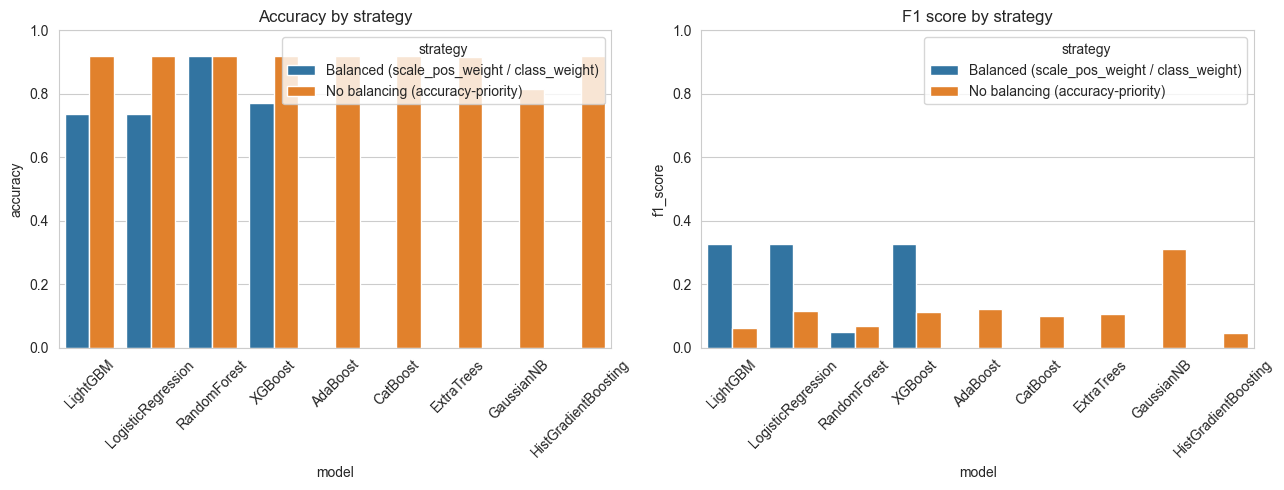

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=comparison, x='model', y='accuracy', hue='strategy', ax=axes[0])
axes[0].set_title('Accuracy by strategy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison, x='model', y='f1_score', hue='strategy', ax=axes[1])
axes[1].set_title('F1 score by strategy')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**What the two experiments show:**

- **Balanced strategy (Step 7-8)**: accuracy drops to ~0.73-0.77 for XGBoost/LightGBM/LogisticRegression,
  but F1 rises to ~0.32-0.33. The model actively tries to catch minority-class (heart disease) cases,
  at the cost of more false alarms on healthy people.
- **No-balancing strategy (Step 9)**: accuracy jumps above 0.9 for almost every model, but F1 collapses
  to ~0.04-0.13. This happens because ~92% of the data is the negative class — a model can reach ~0.92
  accuracy by predicting "No disease" almost every time, which is not a useful diagnostic tool.

**Practical takeaway:**

- If the goal is a **screening tool** (don't miss people who may have heart disease), the balanced
  strategy is the right choice, even though its accuracy number looks worse — recall/F1 on the positive
  class is what matters clinically.
- If the goal is just to **report a high accuracy metric** (e.g. for a course requirement or benchmark),
  the no-balancing strategy achieves that, but the number is misleading in this imbalanced setting.
- Accuracy alone is not a reliable metric here. ROC-AUC or F1 (or Recall) on the positive class should be
  reported alongside it, or instead of it, to see whether a model actually distinguishes the two classes.
- Among the two experiments, **XGBoost with `scale_pos_weight`** (Step 7-8) gives the best balance: decent
  F1 (~0.33) without accuracy collapsing entirely (~0.77).


## Step 11: Confusion Matrix & ROC Curve

Based on the Step 10 conclusion, XGBoost with `scale_pos_weight` (balanced strategy)
is the practical choice. This section evaluates it in more detail than plain
accuracy/F1: confusion matrix (how many disease cases are missed) and ROC-AUC
(threshold-independent separation ability).


In [37]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
spw = (y_train == 0).sum() / (y_train == 1).sum()

best_model = XGBClassifier(n_estimators=300, eval_metric='logloss',
                            scale_pos_weight=spw, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

               precision    recall  f1-score   support

   No Disease       0.97      0.78      0.86     56777
Heart Disease       0.22      0.69      0.33      4994

     accuracy                           0.77     61771
    macro avg       0.59      0.73      0.60     61771
 weighted avg       0.91      0.77      0.82     61771



### Confusion matrix

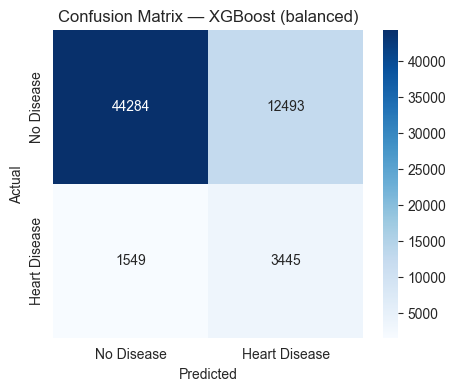

Missed disease cases (False Negative): 1549 out of 4994 actual cases (31.0%)


In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost (balanced)')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Missed disease cases (False Negative): {fn} out of {fn + tp} actual cases '
      f'({fn / (fn + tp):.1%})')

### ROC curve

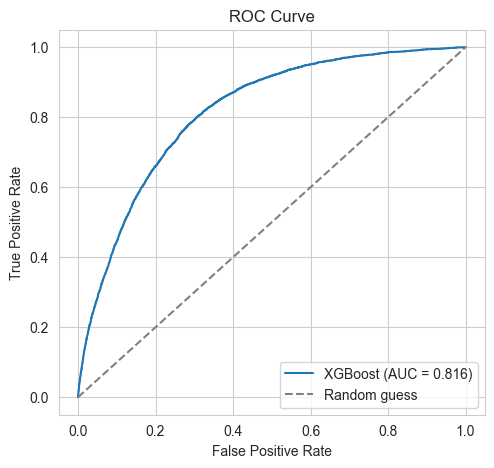

ROC-AUC: 0.816


In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print('ROC-AUC:', round(auc, 4))

## Step 12: Feature Importance

Shows which features XGBoost relies on most, including whether the engineered
features from Step 2 (`BMI_Category`, `Comorbidity_Count`, `Unhealthy_Diet_Score`)
turned out to be useful.


/var/folders/6l/qcszjyt91cs2k6qn1d8d23h40000gn/T/ipykernel_33807/4009702492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette=colors)


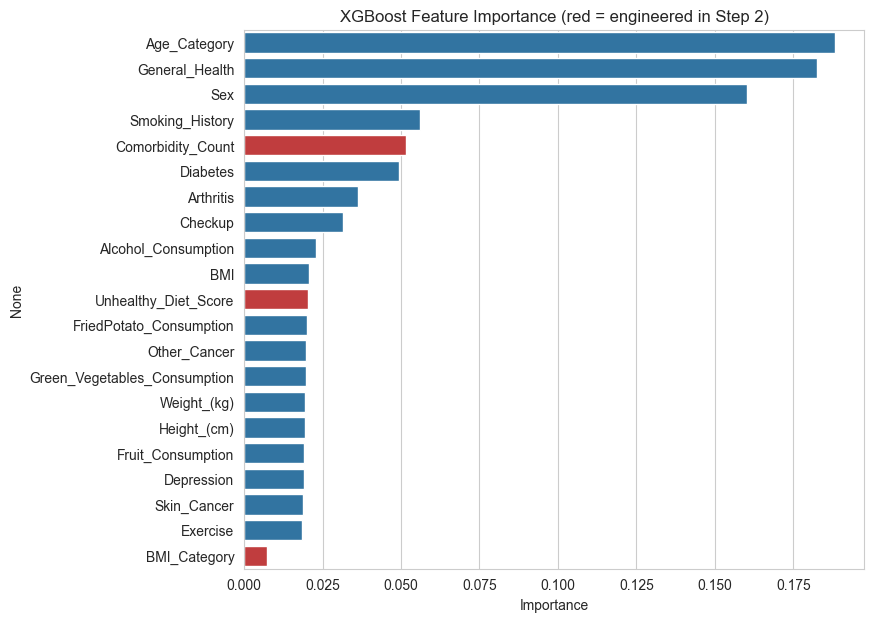

Age_Category                    0.188185
General_Health                  0.182541
Sex                             0.160133
Smoking_History                 0.055912
Comorbidity_Count               0.051479
Diabetes                        0.049425
Arthritis                       0.036200
Checkup                         0.031536
Alcohol_Consumption             0.022826
BMI                             0.020571
Unhealthy_Diet_Score            0.020220
FriedPotato_Consumption         0.019979
Other_Cancer                    0.019645
Green_Vegetables_Consumption    0.019565
Weight_(kg)                     0.019428
Height_(cm)                     0.019412
Fruit_Consumption               0.019211
Depression                      0.019136
Skin_Cancer                     0.018645
Exercise                        0.018514
BMI_Category                    0.007435
dtype: float32

In [40]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

engineered_features = ['BMI_Category', 'Comorbidity_Count', 'Unhealthy_Diet_Score']
colors = ['#d62728' if f in engineered_features else '#1f77b4' for f in importance.index]

plt.figure(figsize=(8, 7))
sns.barplot(x=importance.values, y=importance.index, palette=colors)
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance (red = engineered in Step 2)')
plt.show()

importance


In [41]:
print('Rank of engineered features:')
rank = importance.reset_index()
rank.columns = ['feature', 'importance']
rank.index = rank.index + 1
rank[rank['feature'].isin(engineered_features)]

Rank of engineered features:


,feature,importance
5,Comorbidity_Count,0.051479
11,Unhealthy_Diet_Score,0.020220
21,BMI_Category,0.007435


## Step 13: Export Model for the Streamlit Application

Saves the trained XGBoost model (balanced strategy) and the exact feature
column order, so the Streamlit app in Section 6 can load it directly instead
of retraining.

In [42]:
import joblib

joblib.dump(best_model, 'xgb_heart_disease_model.pkl')
joblib.dump(list(X.columns), 'model_feature_columns.pkl')
print('Saved model and feature column order.')
print(list(X.columns))

Saved model and feature column order.
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'BMI_Category', 'Comorbidity_Count', 'Unhealthy_Diet_Score']
